In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import DQN as SB3DQN
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

from rl.train import train
from rl.evaluate import (
    make_env,
    evaluate_custom_agent,
    evaluate_sb3_model,
    record_custom_rollout,
    record_sb3_rollout,
    find_custom_failure_case,
    find_sb3_failure_case,
)
from rl.visualize import (
    plot_training_curve,
    make_results_table,
    plot_metric_comparison,
    show_side_by_side_gifs,
    print_failure_case,
)

TRAIN_SEEDS = [0, 1, 2]
EVAL_SEEDS = list(range(1000, 1050))

TOTAL_STEPS = 20_000
LEARNING_STARTS = 1_000

ARTIFACTS = Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)

custom_agents = {}
custom_metrics = {}
custom_rows = []

sb3_models = {}
sb3_rows = []

custom_extension_agents = {}
custom_extension_metrics = {}
custom_extension_rows = []


In [ ]:
for seed in TRAIN_SEEDS:
    agent, metrics = train(seed=seed, run_dir=ARTIFACTS / "custom" / f"seed_{seed}")
    custom_agents[seed] = agent
    custom_metrics[seed] = metrics

    result = evaluate_custom_agent(agent, EVAL_SEEDS)
    custom_rows.append(
        {
            "algo": "custom_dqn",
            "train_seed": seed,
            "mean_return": result["mean_return"],
            "std_return": result["std_return"],
            "mean_length": result["mean_length"],
            "crash_rate": result["crash_rate"],
        }
    )


In [ ]:
from rl.train import train
for seed in TRAIN_SEEDS:
    extension_agent, extension_metrics = train(seed=seed, run_dir=ARTIFACTS / "custom" / f"seed_{seed}", double_dqn=True)
    custom_extension_agents[seed] = extension_agent
    custom_extension_metrics[seed] = extension_metrics

    result = evaluate_custom_agent(extension_agent, EVAL_SEEDS)
    custom_extension_rows.append(
        {
            "algo": "custom_ddqn_per",
            "train_seed": seed,
            "mean_return": result["mean_return"],
            "std_return": result["std_return"],
            "mean_length": result["mean_length"],
            "crash_rate": result["crash_rate"],
        }
    )


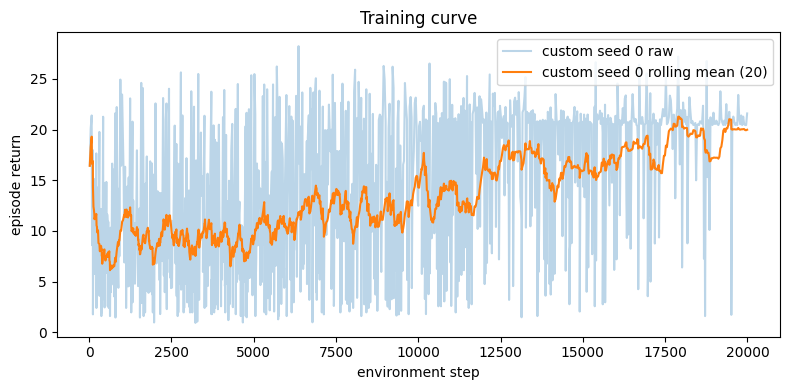

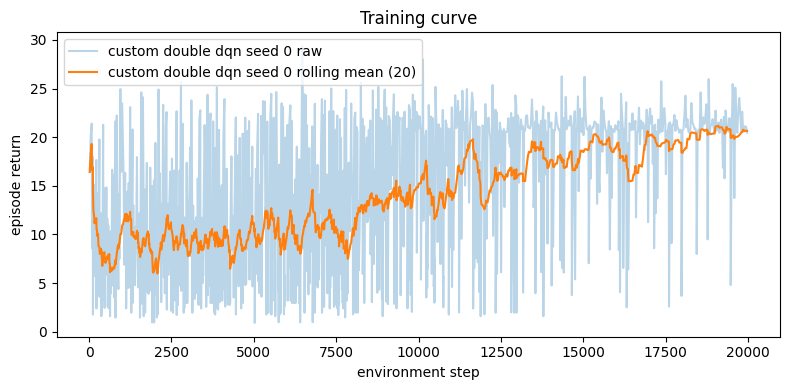

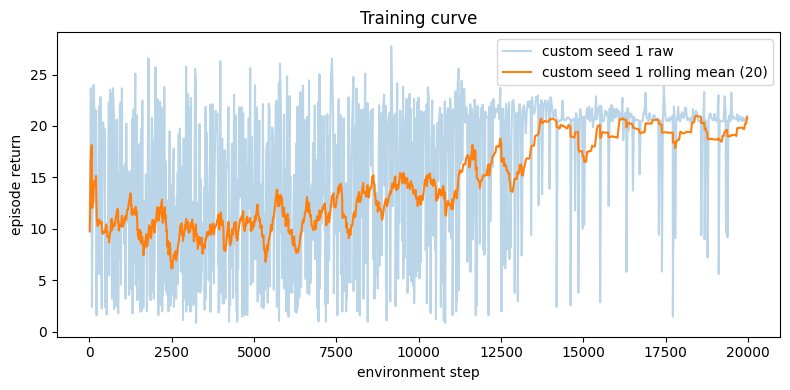

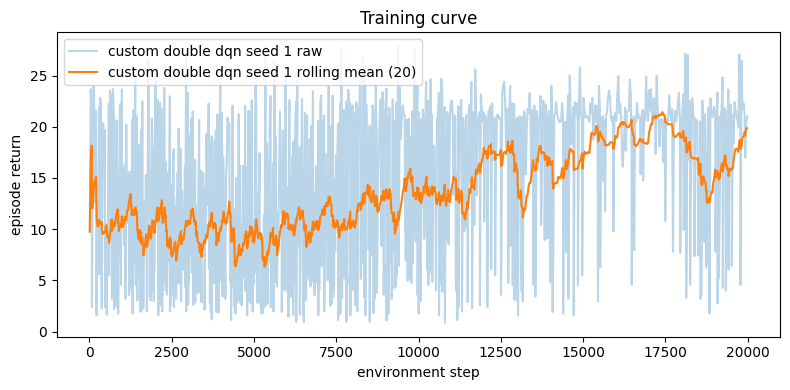

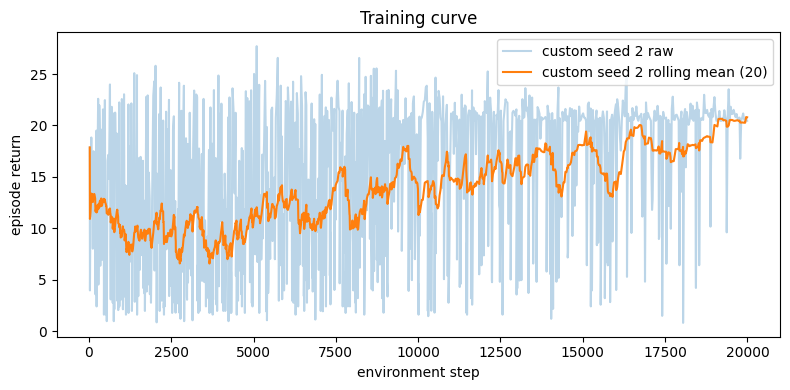

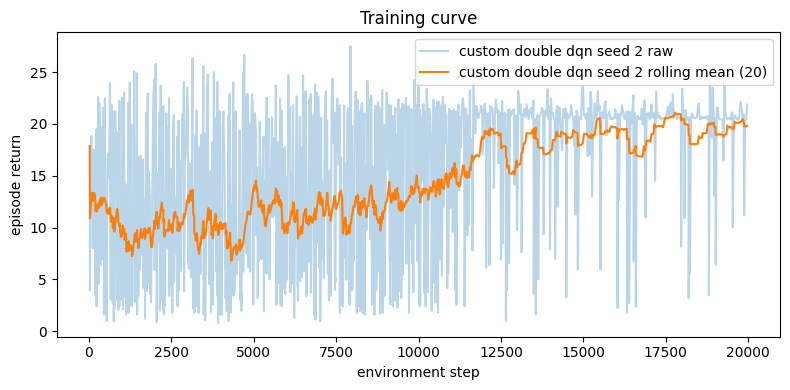

In [21]:
for seed in TRAIN_SEEDS:
    plot_training_curve(custom_metrics[seed], label=f"custom seed {seed}")
    plot_training_curve(custom_extension_metrics[seed], label=f"custom double dqn seed {seed}")


In [12]:
for seed in TRAIN_SEEDS:
    run_dir = ARTIFACTS / "sb3" / f"seed_{seed}"
    run_dir.mkdir(parents=True, exist_ok=True)

    train_env = Monitor(make_env())
    eval_env = Monitor(make_env())

    train_env.reset(seed=seed)
    eval_env.reset(seed=seed + 10_000)

    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=str(run_dir),
        log_path=str(run_dir),
        eval_freq=1000,
        n_eval_episodes=10,
        deterministic=True,
        render=False,
        verbose=0,
    )

    model = SB3DQN(
        "MlpPolicy",
        train_env,
        seed=seed,
        learning_rate=1e-3,
        buffer_size=10_000,
        learning_starts=LEARNING_STARTS,
        batch_size=32,
        gamma=0.99,
        train_freq=1,
        gradient_steps=1,
        target_update_interval=1000,
        exploration_initial_eps=1.0,
        exploration_final_eps=0.05,
        exploration_fraction=(TOTAL_STEPS - LEARNING_STARTS) / TOTAL_STEPS,
        policy_kwargs=dict(net_arch=[128, 128]),
        verbose=0,
    )

    model.learn(total_timesteps=TOTAL_STEPS, callback=eval_callback)
    model.save(run_dir / "final_model")

    result = evaluate_sb3_model(model, EVAL_SEEDS)
    sb3_models[seed] = model
    sb3_rows.append(
        {
            "algo": "sb3_dqn",
            "train_seed": seed,
            "mean_return": result["mean_return"],
            "std_return": result["std_return"],
            "mean_length": result["mean_length"],
            "crash_rate": result["crash_rate"],
        }
    )

    train_env.close()
    eval_env.close()


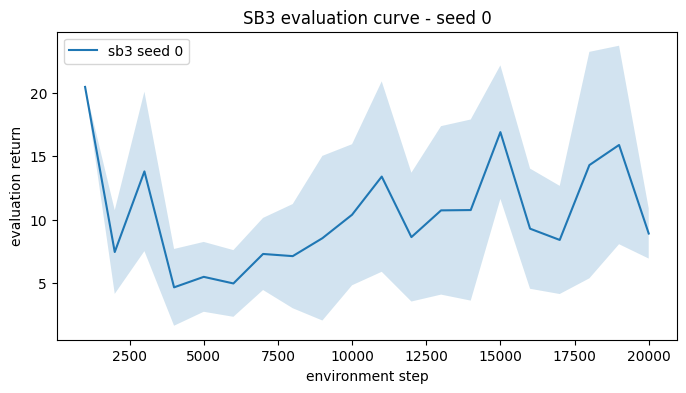

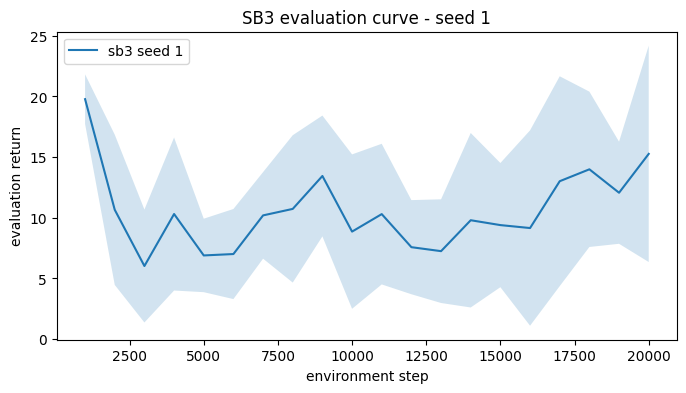

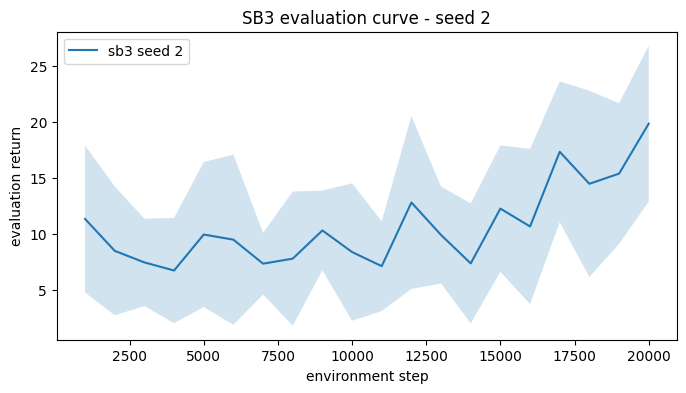

In [13]:
for seed in TRAIN_SEEDS:
    eval_file = ARTIFACTS / "sb3" / f"seed_{seed}" / "evaluations.npz"
    data = np.load(eval_file)

    timesteps = data["timesteps"]
    results = data["results"]

    plt.figure(figsize=(8, 4))
    plt.plot(timesteps, results.mean(axis=1), label=f"sb3 seed {seed}")
    plt.fill_between(
        timesteps,
        results.mean(axis=1) - results.std(axis=1),
        results.mean(axis=1) + results.std(axis=1),
        alpha=0.2,
    )
    plt.xlabel("environment step")
    plt.ylabel("evaluation return")
    plt.title(f"SB3 evaluation curve - seed {seed}")
    plt.legend()
    plt.show()


,algo,train_seed,mean_return,std_return,mean_length,crash_rate
0,custom_dqn,0,20.139,3.787,28.067,0.133
1,sb3_dqn,0,17.255,6.870,22.320,0.453
2,custom_ddqn_per,0,19.921,2.841,28.680,0.073


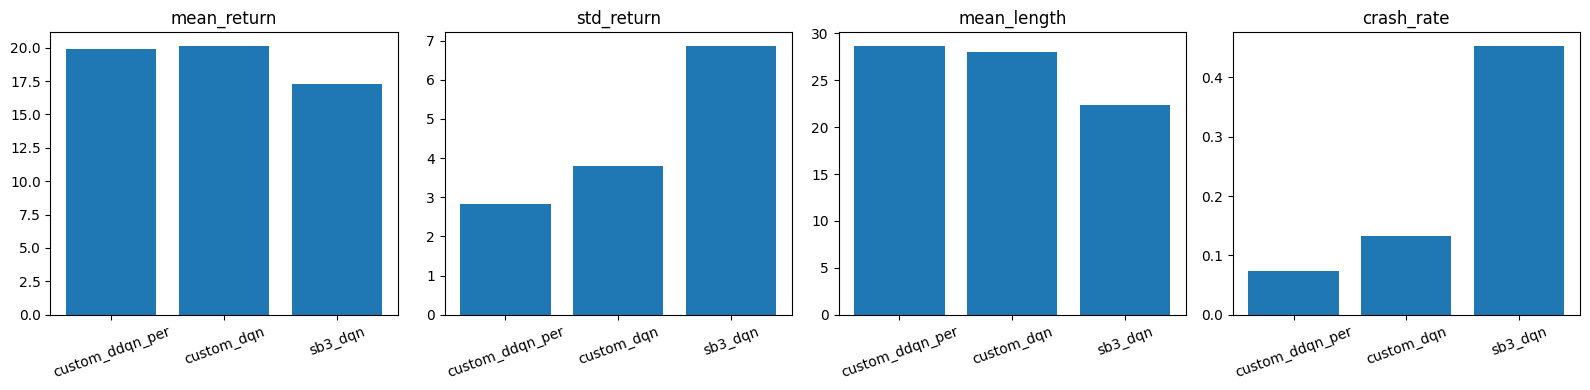

In [ ]:
all_rows = custom_rows + custom_extension_rows + sb3_rows

df, summary = make_results_table(all_rows)

display(df)

plot_metric_comparison(df)


In [15]:
custom_rollout = record_custom_rollout(
    custom_agents[0],
    seed=1235,
    gif_path=ARTIFACTS / "rollouts" / "custom_seed0.gif",
)

custom_extension_rollout = record_custom_rollout(
    custom_extension_agents[0],
    seed=1235,
    gif_path=ARTIFACTS / "rollouts" / "custom_extension_seed0.gif",
)

sb3_rollout = record_sb3_rollout(
    sb3_models[0],
    seed=1235,
    gif_path=ARTIFACTS / "rollouts" / "sb3_seed0.gif",
)

show_side_by_side_gifs(
    custom_rollout["gif_path"],
    custom_extension_rollout["gif_path"],
    sb3_rollout["gif_path"],
    left_title="Custom DQN",
    middle_title="Custom Double DQN",
    right_title="SB3 DQN",
)

custom_rollout, custom_extension_rollout, sb3_rollout


({'gif_path': 'artifacts\\rollouts\\custom_seed0.gif',
  'return': 20.454545454545464,
  'crashed': False,
  'seed': 1235},
 {'gif_path': 'artifacts\\rollouts\\custom_extension_seed0.gif',
  'return': 21.489563135154757,
  'crashed': False,
  'seed': 1235},
 {'gif_path': 'artifacts\\rollouts\\sb3_seed0.gif',
  'return': 6.117852095060695,
  'crashed': True,
  'seed': 1235})

Custom DQN failure case: seed=2006, return=14.95, crashed=True


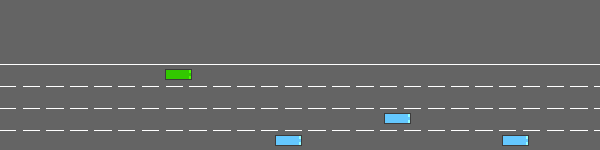

Custom Double DQN failure case: seed=2010, return=25.93, crashed=True


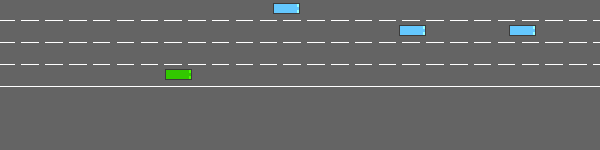

SB3 DQN failure case: seed=2000, return=20.95, crashed=True


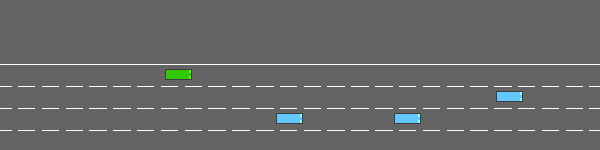

In [19]:
custom_failure = find_custom_failure_case(custom_agents[0], range(2000, 2100))
custom_extension_failure = find_custom_failure_case(custom_extension_agents[0], range(2000, 2100))
sb3_failure = find_sb3_failure_case(sb3_models[0], range(2000, 2100))

print_failure_case(custom_failure, label="Custom DQN")
print_failure_case(custom_extension_failure, label="Custom Double DQN")
print_failure_case(sb3_failure, label="SB3 DQN")
